- ## Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import time

from scipy.interpolate import CubicSpline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

- ## Load the Datasets

In [2]:
RAW_GAP10 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_10.csv"
)

RAW_GAP30 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_30.csv"
)

RAW_GAP50 = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/corrupted_data/gap_50.csv"
)

gap10 = pd.read_csv(RAW_GAP10)
gap30 = pd.read_csv(RAW_GAP30)
gap50 = pd.read_csv(RAW_GAP50)

datasets = {
    "10": gap10,
    "30": gap30,
    "50": gap50
}

print("Datasets loaded successfully.")

Datasets loaded successfully.


- ## Cubic Spline Function

In [6]:
def cubic_spline_imputation(df):
    """
    Perform Cubic Spline interpolation using SciPy.

    Missing values are reconstructed using only the
    observed data points.
    """

    result = df.copy()

    observed = result["mask"] == 1

    x_train = result.loc[observed, "time"].values

    y_train = result.loc[
        observed,
        "corrupted_flux"
    ].values

    spline = CubicSpline(
        x_train,
        y_train,
        bc_type="natural"
    )

    result["imputed_flux"] = spline(
        result["time"].values
    )

    return result

- ## Apply the Imputation

In [7]:
results = {}

metrics = []

for level, df in datasets.items():

    start = time.perf_counter()

    reconstructed = cubic_spline_imputation(df)

    runtime = time.perf_counter() - start

    results[level] = reconstructed

    missing = reconstructed["mask"] == 0

    y_true = reconstructed.loc[
        missing,
        "ideal_flux"
    ].values

    y_pred = reconstructed.loc[
        missing,
        "imputed_flux"
    ].values

    # Safety check
    if np.isnan(y_pred).any():

        raise ValueError(
            "NaN values remain after spline interpolation."
        )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    metrics.append({

        "Method": "Cubic Spline",

        "Missing (%)": int(level),

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2,

        "Runtime (s)": runtime

    })

metrics = pd.DataFrame(metrics)

metrics

,Method,Missing (%),RMSE,MAE,R2,Runtime (s)
0,Cubic Spline,10,0.095927,0.070275,-0.769374,0.005498
1,Cubic Spline,30,0.144506,0.090788,-3.026479,0.005546
2,Cubic Spline,50,0.124017,0.070555,-2.091891,0.011460


- ## Verify No NaNs

In [8]:
for level, df in results.items():

    print("=" * 40)

    print(f"{level}% Missing")

    print(
        "Remaining NaNs:",
        df["imputed_flux"].isna().sum()
    )

10% Missing
Remaining NaNs: 0
30% Missing
Remaining NaNs: 0
50% Missing
Remaining NaNs: 0


- ## Plot Reconstruction

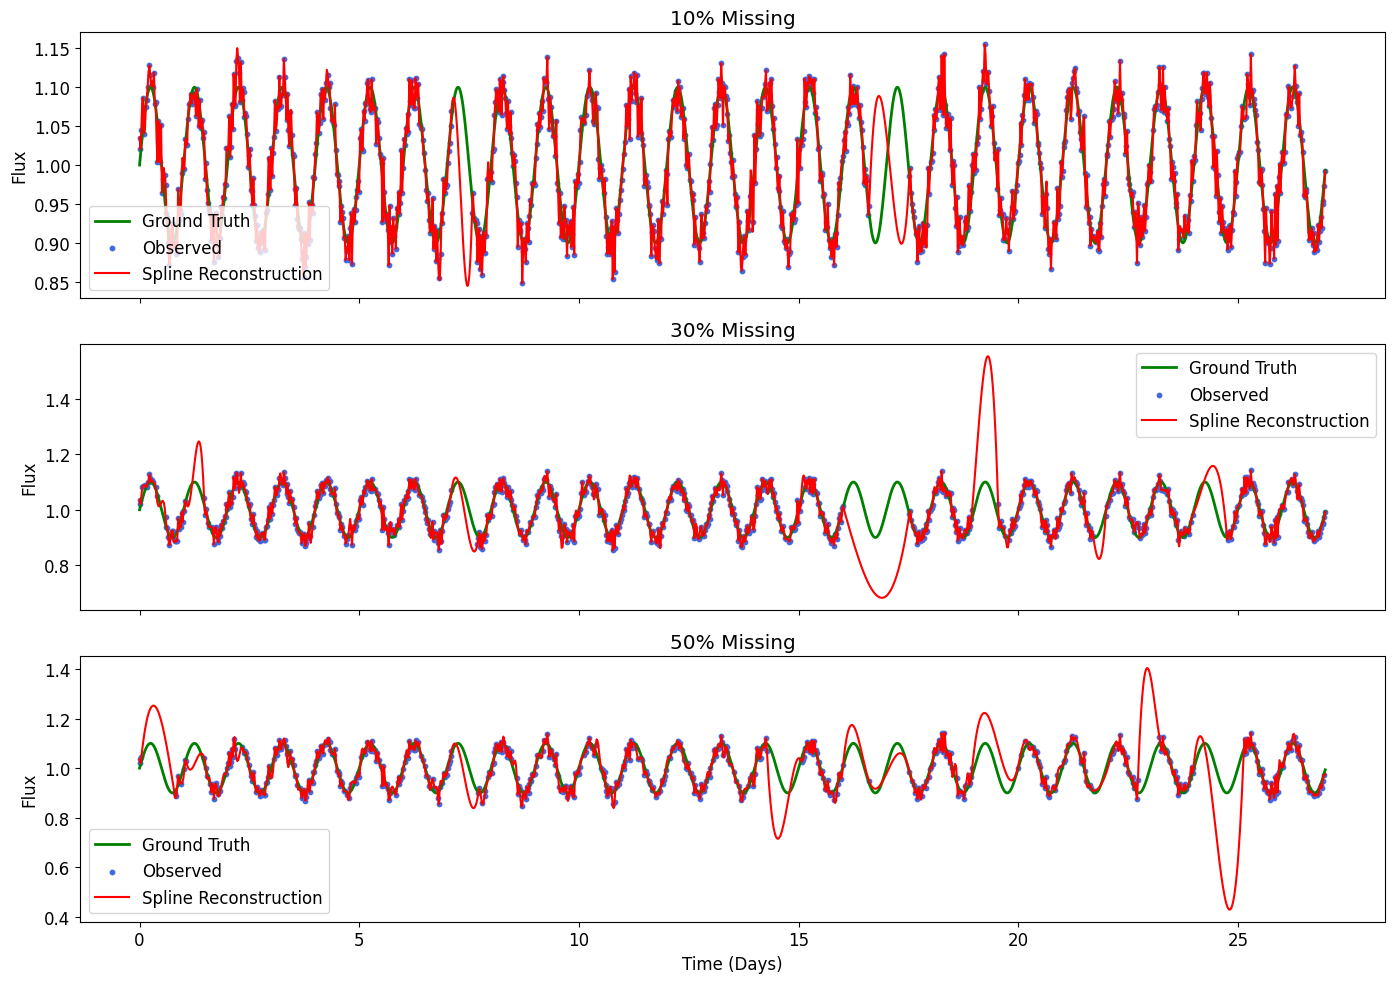

In [9]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

for ax, (level, df) in zip(axes, results.items()):

    ax.plot(
        df["time"],
        df["ideal_flux"],
        color="green",
        linewidth=2,
        label="Ground Truth"
    )

    ax.scatter(
        df["time"],
        df["corrupted_flux"],
        s=10,
        color="royalblue",
        label="Observed"
    )

    ax.plot(
        df["time"],
        df["imputed_flux"],
        color="red",
        linewidth=1.5,
        label="Spline Reconstruction"
    )

    ax.set_title(f"{level}% Missing")

    ax.set_ylabel("Flux")

    ax.legend()

plt.xlabel("Time (Days)")

plt.tight_layout()

plt.show()

- ## Save Reconstructed Data

In [10]:
OUTPUT_DIR = Path(
    "data/imputed_data/cubic_spline"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for level, df in results.items():

    df.to_csv(
        OUTPUT_DIR / f"cubic_spline_{level}.csv",
        index=False
    )

print("Reconstructed datasets saved.")

Reconstructed datasets saved.


- ## Save Metrics

In [11]:
RESULT_DIR = Path("results")

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

metrics.to_csv(
    RESULT_DIR / "cubic_spline_metrics.csv",
    index=False
)

print(metrics)

         Method  Missing (%)      RMSE       MAE        R2  Runtime (s)
0  Cubic Spline           10  0.095927  0.070275 -0.769374     0.005498
1  Cubic Spline           30  0.144506  0.090788 -3.026479     0.005546
2  Cubic Spline           50  0.124017  0.070555 -2.091891     0.011460
